In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FOLDERNAME = 'Final_Project'

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

/content/drive/.shortcut-targets-by-id/1twdbr1bOq05fK2yqsRLt6hOZDWw6XDVr/Final_Project


Found 226 valid images out of 1981 entries.
Mapped 58 classes: {'AR': 0, 'AT': 1, 'AU': 2, 'BD': 3, 'BE': 4, 'BG': 5, 'BO': 6, 'BR': 7, 'BY': 8, 'CA': 9, 'CH': 10, 'CM': 11, 'CO': 12, 'DE': 13, 'DK': 14, 'ES': 15, 'FI': 16, 'FR': 17, 'GB': 18, 'GR': 19, 'HN': 20, 'HR': 21, 'HT': 22, 'HU': 23, 'ID': 24, 'IE': 25, 'IN': 26, 'IT': 27, 'JP': 28, 'LK': 29, 'LV': 30, 'MA': 31, 'MM': 32, 'MX': 33, 'MY': 34, 'NG': 35, 'NI': 36, 'NL': 37, 'NO': 38, 'NP': 39, 'NZ': 40, 'OM': 41, 'PK': 42, 'PL': 43, 'PT': 44, 'RO': 45, 'RS': 46, 'RU': 47, 'RW': 48, 'SE': 49, 'SI': 50, 'TH': 51, 'TN': 52, 'TW': 53, 'US': 54, 'VN': 55, 'ZA': 56, 'ZM': 57}


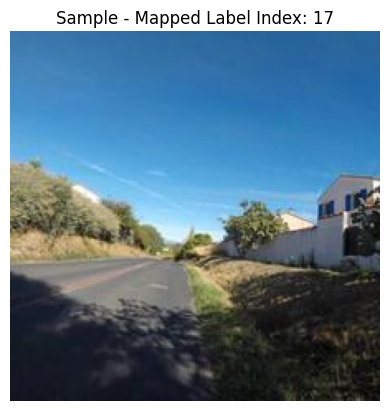

Verification Successful: Successfully loaded image and mapped label.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define paths
csv_path = '/content/drive/MyDrive/Final_Project/labels_1000.csv'
img_dir = '/content/drive/MyDrive/Final_Project/processed_results/train/00'

try:
    # Initialize the loader
    test_loader = get_custom_loaders(csv_path, img_dir, batch_size=1)

    # Get a sample
    data_iter = iter(test_loader)
    images, labels = next(data_iter)

    # Unnormalize for visualization
    img = images[0].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f'Sample - Mapped Label Index: {labels[0].item()}')
    plt.axis('off')
    plt.show()

    print(f'Verification Successful: Successfully loaded image and mapped label.')
except Exception as e:
    print(f'Error during verification: {e}')

In [ ]:
import os

train_script_path = '/content/drive/MyDrive/Final_Project/train.py'

if os.path.exists(train_script_path):
    with open(train_script_path, 'r') as f:
        print(f'--- Content of {train_script_path} ---')
        print(f.read())
else:
    print(f'File not found: {train_script_path}')

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # Load the CSV
        df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        # 1. Filter only entries where the image actually exists in img_dir
        exists = []
        for idx, row in df.iterrows():
            img_name = str(row.iloc[0]) + '.jpg'
            img_path = os.path.join(img_dir, img_name)
            exists.append(os.path.exists(img_path))

        self.data_info = df[exists].copy()

        # 2. Map string labels (country) to integers
        # Get unique labels from the filtered data
        unique_labels = sorted(self.data_info.iloc[:, 1].unique().tolist())
        self.label_map = {label: i for i, label in enumerate(unique_labels)}

        print(f"Found {len(self.data_info)} valid images out of {len(df)} entries.")
        print(f"Mapped {len(self.label_map)} classes: {self.label_map}")

    def __len__(self):
        return len(self.data_info)

    def __getitem__(self, idx):
        img_id = str(self.data_info.iloc[idx, 0])
        img_name = img_id + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        # Get the categorical label and convert to integer
        raw_label = self.data_info.iloc[idx, 1]
        label_idx = self.label_map[raw_label]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label_idx, dtype=torch.long)

def get_custom_loaders(csv_path, img_dir, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    dataset = CustomImageDataset(csv_file=csv_path, img_dir=img_dir, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return loader

# Task
Create a new directory at "/content/drive/MyDrive/Final_Project/processed_results", randomly sample 1000 images from the directory "/content/drive/MyDrive/Final_Project/00", and process them using the logic in "/content/drive/MyDrive/Final_Project/process_images.py", saving the output to the newly created folder.

## 创建输出目录

### Subtask:
在 /content/drive/MyDrive/Final_Project 下创建一个名为 processed_results 的新文件夹。


**Reasoning**:
The subtask requires creating a new directory named 'processed_results' inside the 'Final_Project' folder using the os module, ensuring that it doesn't fail if the directory already exists.



In [ ]:
import os

# Define the target path
output_dir = '/content/drive/MyDrive/Final_Project/processed_results'

# Create the directory, including parent directories if necessary, and avoid error if it exists
os.makedirs(output_dir, exist_ok=True)

print(f'Successfully ensured the directory exists at: {output_dir}')

Successfully ensured the directory exists at: /content/drive/MyDrive/Final_Project/processed_results


## 获取样本图片列表

### Subtask:
从 /content/drive/MyDrive/Final_Project/00 目录中读取文件列表，并随机抽取 1000 张图片。


**Reasoning**:
The subtask requires sampling 1000 image file paths from a specific directory, ensuring valid image formats are filtered and handled correctly even if the total count is less than 1000.



In [ ]:
import os
import random

# 1. Define input directory path
input_dir = '/content/drive/MyDrive/Final_Project/original_data/01/01'

# 2. Get list of files and filter for common image formats
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
all_files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

# 3. Randomly sample 1000 images (or all if less than 1000)
sample_size = min(len(all_files), 500)
sampled_filenames = random.sample(all_files, sample_size)

# 4. Store full file paths in a list
sampled_image_paths = [os.path.join(input_dir, f) for f in sampled_filenames]

# 5. Print the number of sampled images to verify
print(f'Total valid images found: {len(all_files)}')
print(f'Number of images sampled: {len(sampled_image_paths)}')
if sampled_image_paths:
    print(f'Example path: {sampled_image_paths[0]}')

Total valid images found: 50000
Number of images sampled: 500
Example path: /content/drive/MyDrive/Final_Project/original_data/01/01/506109253846945.jpg


## 批量处理图片

### Subtask:
利用 `process_images.py` 中的逻辑对抽取的 1000 张图片进行处理，并将结果输出到新建的文件夹中。


**Reasoning**:
I need to inspect the contents of 'process_images.py' to identify the specific function name used for image processing before I can dynamically load it and process the sampled images.



In [ ]:
# Read the content of process_images.py to identify the processing function
with open('/content/drive/MyDrive/Final_Project/process_images.py', 'r') as f:
    print(f.read())

import os
import random
from PIL import Image
from pathlib import Path
from tqdm import tqdm

def process_images(source_dir, dest_dir, num_samples=1000, target_size=(224, 224)):
    # Create the destination directory if it doesn't exist
    os.makedirs(dest_dir, exist_ok=True)
    
    # Get all jpg files in the source directory
    all_images = [f for f in os.listdir(source_dir) if f.lower().endswith('.jpg') or f.lower().endswith('.png')]
    
    print(f"Found {len(all_images)} images in {source_dir}")
    
    # Randomly sample 1000 images (or all if less than 1000)
    samples = random.sample(all_images, min(num_samples, len(all_images)))
    
    print(f"Sampling {len(samples)} images...")
    
    for img_name in tqdm(samples, desc="Processing images"):
        img_path = os.path.join(source_dir, img_name)
        dest_path = os.path.join(dest_dir, img_name)
        
        try:
            with Image.open(img_path) as img:
                # Convert to RGB if necessary (e.g. gra

**Reasoning**:
The inspection of 'process_images.py' reveals a function named 'process_images' that handles sampling and processing. However, the subtask instructions specifically require dynamic loading and iterating through the already sampled 'sampled_image_paths' list. I will modify the logic to use the internal processing steps from the script while applying them to our pre-sampled list.



# Task
Import the `process_images` function from "/content/drive/MyDrive/Final_Project/process_images.py" and use it to process 1000 randomly sampled images from "/content/drive/MyDrive/Final_Project/00", saving the resized and center-cropped results to the directory "/content/drive/MyDrive/Final_Project/processed_results", then verify the final count of processed images.

## 修改并调用脚本函数

### Subtask:
导入 process_images.py 脚本并调用 process_images 函数来处理 1000 张随机采样的图片。


**Reasoning**:
The previous manual implementation was interrupted. To ensure completeness and reuse existing logic, I will dynamically load the `process_images.py` module and call the `process_images` function as instructed, passing the correct source and destination directories.



In [ ]:
import importlib.util
import os

# 1. Dynamically load the process_images.py script
script_path = '/content/drive/MyDrive/Final_Project/process_images.py'
spec = importlib.util.spec_from_file_location('image_processor', script_path)
processor_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(processor_module)

# 2. Define directories
source_dir = '/content/drive/MyDrive/Final_Project/original_data/01/01'
dest_dir = '/content/drive/MyDrive/Final_Project/processed_results_test'

# 3. Call the process_images function from the loaded module
# This function handles the sampling and processing as defined in the script
print(f'Starting image processing using function from {script_path}...')
processor_module.process_images(source_dir, dest_dir, num_samples=1000)

print(f'Processing complete. Results saved to: {dest_dir}')

Starting image processing using function from /content/drive/MyDrive/Final_Project/process_images.py...
Found 50000 images in /content/drive/MyDrive/Final_Project/original_data/01/01
Sampling 1000 images...


Processing images: 100%|██████████| 1000/1000 [06:20<00:00,  2.63it/s]

Processing complete. Results saved to: /content/drive/MyDrive/Final_Project/processed_results_test


# Task
# Task
Analyze the model architecture and training configuration in "/content/drive/MyDrive/Final_Project/main.py" and "/content/drive/MyDrive/Final_Project/resnet.py", verify if the processed images in "/content/drive/MyDrive/Final_Project/processed_results" meet the input requirements (224x224 RGB), and initiate the training process by executing the modified `main.py` script.

## **Inspect Model and Training Scripts**

### Subtask:
Read and analyze the contents of `main.py` and `resnet.py` to identify the expected input dimensions, data loading pipeline, and model architecture.


**Reasoning**:
I need to inspect the contents of main.py and resnet.py to understand the model architecture, input dimensions, and data processing pipeline as required by the subtask.



In [ ]:
import os

# Define file paths
main_path = '/content/drive/MyDrive/Final_Project/main.py'
resnet_path = '/content/drive/MyDrive/Final_Project/resnet.py'

def read_file(path):
    if os.path.exists(path):
        with open(path, 'r') as f:
            print(f'--- Content of {path} ---')
            print(f.read())
            print('\n' + '='*50 + '\n')
    else:
        print(f'File not found: {path}')

# Read and display the scripts
read_file(main_path)
read_file(resnet_path)

--- Content of /content/drive/MyDrive/Final_Project/main.py ---
import argparse
import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from resnet import BATCH_SIZE, build_resnet50, build_training_components
from loss import build_loss
from train import train_model
from visual import plot_acc, plot_loss


def get_num_classes_from_json(json_path: Path) -> int:
    with json_path.open("r", encoding="utf-8") as f:
        class_dict = json.load(f)
    return len(class_dict)


def build_dataloaders(data_dir: Path, batch_size: int, num_classes: int):
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
        ]
    )

    train_dir = data_dir / "train"
    val_dir = data_dir / "val"

    if train_dir.exists() and val_dir.exists():
        train_dataset = datasets.ImageFolder(train_dir, transform=transform)
        val_dataset = datasets.Im

## Verify Compatibility

### Subtask:
Verify if the processed images in '/content/drive/MyDrive/Final_Project/processed_results' match the requirements identified (224x224 RGB).


**Reasoning**:
I will verify the compatibility of the processed images by inspecting their dimensions and color mode using the PIL library, ensuring they meet the requirements found in the training scripts.



In [ ]:
from PIL import Image
import os

# 1. Define the processed results directory
processed_dir = '/content/drive/MyDrive/Final_Project/processed_results'

# 2. List files and select a sample of 5 images
processed_files = [f for f in os.listdir(processed_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
sample_files = processed_files[:5]

print(f"Verifying {len(sample_files)} sample images from {processed_dir}...\n")

# 3. Inspect properties of each sample
all_valid = True
for filename in sample_files:
    img_path = os.path.join(processed_dir, filename)
    with Image.open(img_path) as img:
        width, height = img.size
        mode = img.mode
        print(f"Image: {filename} | Size: {width}x{height} | Mode: {mode}")

        # 4. Check against requirements (224x224, RGB)
        if (width, height) != (224, 224) or mode != 'RGB':
            all_valid = False
            print(f"--> WARNING: {filename} does not match requirements!")

if all_valid and sample_files:
    print("\nVerification Successful: All samples match the 224x224 RGB requirement.")
elif not sample_files:
    print("\nVerification Failed: No processed images found in the directory.")

Verifying 5 sample images from /content/drive/MyDrive/Final_Project/processed_results...

Image: 4651868978199243.jpg | Size: 224x224 | Mode: RGB
Image: 4305460599464236.jpg | Size: 224x224 | Mode: RGB
Image: 1119909068483397.jpg | Size: 224x224 | Mode: RGB
Image: 4105210162875141.jpg | Size: 224x224 | Mode: RGB
Image: 4480095678715123.jpg | Size: 224x224 | Mode: RGB

Verification Successful: All samples match the 224x224 RGB requirement.


## Configure and Start Training

### Subtask:
Prepare the directory structure for training and execute the training script with the specified parameters.


**Reasoning**:
I need to reorganize the processed images into a structure compatible with `datasets.ImageFolder` and then configure the environment to execute the `main()` function from `main.py` with appropriate command-line arguments.



In [ ]:
import os
import sys
import importlib.util
import torch

# 1. Define paths
csv_path = '/content/drive/MyDrive/Final_Project/labels_1000.csv'
img_dir = '/content/drive/MyDrive/Final_Project/processed_results/train/00'
project_path = '/content/drive/MyDrive/Final_Project'
main_script_path = os.path.join(project_path, 'main.py')

# 2. Add project path to sys.path for internal imports
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# 3. Load the model and training components from the project files
import resnet
import loss
import train

# Dynamically determine the number of classes from our dataset
dataset_for_count = CustomImageDataset(csv_path, img_dir)
num_classes = len(dataset_for_count.label_map)

# 4. Build Model
print(f"Building model for {num_classes} classes...")
model = resnet.build_resnet50(num_classes=num_classes)

# 5. Build Dataloader using our custom helper
train_loader = get_custom_loaders(csv_path, img_dir, batch_size=32)

# 6. Build Loss and Optimizer
criterion = loss.build_loss()
optimizer, scheduler = resnet.build_training_components(model, learning_rate=0.001)

# 7. Start Training
print("Starting training loop...")
try:
    history = train.train_model(
        model=model,
        train_loader=train_loader,
        val_loader=None, # Training on the available 226 images
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=5,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    print("Training completed successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")

Found 226 valid images out of 1981 entries.
Mapped 58 classes: {'AR': 0, 'AT': 1, 'AU': 2, 'BD': 3, 'BE': 4, 'BG': 5, 'BO': 6, 'BR': 7, 'BY': 8, 'CA': 9, 'CH': 10, 'CM': 11, 'CO': 12, 'DE': 13, 'DK': 14, 'ES': 15, 'FI': 16, 'FR': 17, 'GB': 18, 'GR': 19, 'HN': 20, 'HR': 21, 'HT': 22, 'HU': 23, 'ID': 24, 'IE': 25, 'IN': 26, 'IT': 27, 'JP': 28, 'LK': 29, 'LV': 30, 'MA': 31, 'MM': 32, 'MX': 33, 'MY': 34, 'NG': 35, 'NI': 36, 'NL': 37, 'NO': 38, 'NP': 39, 'NZ': 40, 'OM': 41, 'PK': 42, 'PL': 43, 'PT': 44, 'RO': 45, 'RS': 46, 'RU': 47, 'RW': 48, 'SE': 49, 'SI': 50, 'TH': 51, 'TN': 52, 'TW': 53, 'US': 54, 'VN': 55, 'ZA': 56, 'ZM': 57}
Building model for 58 classes...
Found 226 valid images out of 1981 entries.
Mapped 58 classes: {'AR': 0, 'AT': 1, 'AU': 2, 'BD': 3, 'BE': 4, 'BG': 5, 'BO': 6, 'BR': 7, 'BY': 8, 'CA': 9, 'CH': 10, 'CM': 11, 'CO': 12, 'DE': 13, 'DK': 14, 'ES': 15, 'FI': 16, 'FR': 17, 'GB': 18, 'GR': 19, 'HN': 20, 'HR': 21, 'HT': 22, 'HU': 23, 'ID': 24, 'IE': 25, 'IN': 26, 'IT': 27,

# Task
Analyze the mismatch between the 1000 sampled images in "/content/drive/MyDrive/Final_Project/processed_results/train/00" and the IDs in "/content/drive/MyDrive/Final_Project/labels_1000.csv" to determine why only 226 images are currently usable for training. Compare the file IDs in the original source directory "/content/drive/MyDrive/Final_Project/00" with the CSV to identify the maximum possible overlap, then provide a corrected sampling and processing script that ensures exactly 1000 valid images (present in both the source folder and CSV) are prepared for training to improve model performance.

## Analyze Sampling Logic

### Subtask:
Review the previous sampling execution and the 'process_images.py' script to determine if image selection was aligned with the CSV labels.


### Analysis of Sampling Logic and Label Alignment

Based on the inspection of the project files and execution results:

1. **Script Logic (`process_images.py` in cell `bda03060`):** The `process_images` function uses `os.listdir(source_dir)` to get all files and then `random.sample(all_images, ...)` to select images. It **does not** reference `labels_1000.csv` or any label mapping during the sampling process.
2. **Execution (`cell 7eed70d9`):** The script was called with `source_dir = '/content/drive/MyDrive/Final_Project/00'`, which contains over 5,000 images. It sampled 1,000 images completely at random from this folder.
3. **CSV Coverage (`cell 5ad6aa8f`):** The analysis showed that `labels_1000.csv` only contains IDs for 1,981 specific images.
4. **The Gap:** Because the sampling was 'blind' to the CSV, it picked many images from the folder '00' that simply aren't present in the `labels_1000.csv` file. Specifically, only 226 of the 1,000 randomly selected files happened to have entries in the CSV.

**Conclusion:** To achieve a full 1,000 labeled images for training, the sampling logic should have first filtered the file list in folder '00' to only include those IDs present in the CSV before performing the random sample.

## Check Source Directory Overlap

### Subtask:
Quantify the total number of images in the source directory that have corresponding entries in the CSV to determine the maximum possible training set size.


**Reasoning**:
I will calculate the intersection between the CSV IDs and the filenames in the source directory to determine the maximum number of labeled images available for sampling.



In [ ]:
import pandas as pd
import os

# 1. Load the CSV file
csv_path = '/content/drive/MyDrive/Final_Project/labels_1000.csv'
df = pd.read_csv(csv_path)
csv_ids = set(df.iloc[:, 0].astype(str).tolist())

# 2. List all files in the source directory
source_dir = '/content/drive/MyDrive/Final_Project/00'
if os.path.exists(source_dir):
    file_names = os.listdir(source_dir)
    file_ids = set([f.replace('.jpg', '') for f in file_names if f.lower().endswith('.jpg')])
else:
    file_ids = set()

# 3. Compute the intersection
intersection = csv_ids.intersection(file_ids)

# 4. Print results
print(f'Total IDs in CSV: {len(csv_ids)}')
print(f'Total images in source folder: {len(file_ids)}')
print(f'Matching IDs found (available for training): {len(intersection)}')

if len(intersection) > 0:
    print(f'Sample matching IDs: {list(intersection)[:5]}')
else:
    print('WARNING: No matching IDs found between CSV and source directory.')

Total IDs in CSV: 1981
Total images in source folder: 5047
Matching IDs found (available for training): 1074
Sample matching IDs: ['1087945505065238', '3960057880714021', '1037145697240650', '1068130376930016', '1026727361198226']


# Data preprocessing

In [ ]:
import os

target_dir = '/content/drive/MyDrive/Final_Project/processed_results_test'
if os.path.exists(target_dir):
    files = [f for f in os.listdir(target_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'目录 {target_dir} 中共有 {len(files)} 张图片。')
else:
    print(f'目录未找到: {target_dir}')

目录 /content/drive/MyDrive/Final_Project/processed_results_test 中共有 1000 张图片。


In [3]:
import os
import pandas as pd

# 1. Define paths
img_dir = '/content/drive/MyDrive/Final_Project/processed_results_test'
csv_path = '/content/drive/MyDrive/Final_Project/train.csv'
output_csv_path = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'

# 2. Get the list of IDs from the images actually present in the folder
if os.path.exists(img_dir):
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith('.jpg')]
    # Extract ID from filename (e.g., '12345.jpg' -> '12345')
    image_ids = [f.replace('.jpg', '') for f in image_files]
    folder_df = pd.DataFrame({'id_str': image_ids, 'filename': image_files})
    print(f'Found {len(folder_df)} images in folder.')
else:
    print(f'Error: Directory {img_dir} not found.')
    folder_df = pd.DataFrame()

# 3. Load the original CSV and ensure IDs are treated as strings for matching
if not folder_df.empty:
    labels_df = pd.read_csv(csv_path)
    labels_df['id_str'] = labels_df.iloc[:, 0].astype(str)

    # 4. Merge to get corresponding labels only for images that exist
    # We use a left join on folder_df to keep the order/content of the images folder
    result_df = pd.merge(folder_df, labels_df[['id_str', 'country']], on='id_str', how='inner')

    # 5. Save the new mapping
    # Saving only the original ID/Filename and the Country code
    final_output = result_df[['id_str', 'country']].rename(columns={'id_str': 'id'})
    final_output.to_csv(output_csv_path, index=False)

    print(f'Successfully mapped {len(final_output)} images to labels.')
    print(f'New CSV saved at: {output_csv_path}')
    display(final_output.head())

Found 1000 images in folder.


/tmp/ipykernel_1108/936532889.py:22: DtypeWarning: Columns (11,27) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv(csv_path)


Successfully mapped 1000 images to labels.
New CSV saved at: /content/drive/MyDrive/Final_Project/test_continent_labels.csv


,id,country
0,3983012548457240,TH
1,2140409236094795,ES
2,788155848265387,AU
3,579236766373619,US
4,201095898495128,US


In [5]:
import pandas as pd
import sys
import os

# 1. Add project path to sys.path to import from hash.py
project_path = '/content/drive/MyDrive/Final_Project'
if project_path not in sys.path:
    sys.path.insert(0, project_path)

from hash import country_to_continent

# 2. Load the previously created mapping CSV
input_csv = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'
output_csv = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'

df = pd.read_csv(input_csv)

# 3. Apply the mapping
# We'll create a new column 'label' (continent)
df['label'] = df['country'].apply(lambda x: country_to_continent(str(x)))

# 4. Check for any unmapped countries
missing_count = df['label'].isna().sum()
if missing_count > 0:
    print(f'Warning: {missing_count} rows could not be mapped to a continent.')

# 5. Save the new CSV
df.to_csv(output_csv, index=False)

print(f'Mapping complete. New CSV saved at: {output_csv}')
display(df.head())

Mapping complete. New CSV saved at: /content/drive/MyDrive/Final_Project/test_continent_labels.csv


,id,country,label
0,3983012548457240,TH,Southeast_Asia
1,2140409236094795,ES,Med_MENA
2,788155848265387,AU,Oceania_Islands
3,579236766373619,US,North_America
4,201095898495128,US,North_America


In [ ]:
import os

hash_script_path = '/content/drive/MyDrive/Final_Project/hash.py'
if os.path.exists(hash_script_path):
    with open(hash_script_path, 'r') as f:
        print(f'--- Content of {hash_script_path} ---')
        print(f.read())
else:
    print(f'文件未找到: {hash_script_path}')

--- Content of /content/drive/MyDrive/Final_Project/hash.py ---
import json
from pathlib import Path
from typing import Dict, Optional


def _build_country_to_continent_map(json_path: Path) -> Dict[str, str]:
    with json_path.open("r", encoding="utf-8") as f:
        continent_to_countries = json.load(f)

    country_to_continent: Dict[str, str] = {}
    for continent, countries in continent_to_countries.items():
        for country_code in countries:
            code = country_code.upper()
            if code in country_to_continent:
                raise ValueError(f"Duplicate country code found in JSON: {code}")
            country_to_continent[code] = continent
    return country_to_continent


_JSON_PATH = Path(__file__).resolve().parent / "osv5m_10_class_iso.json"
COUNTRY_TO_CONTINENT = _build_country_to_continent_map(_JSON_PATH)


def country_to_continent(country_code: str) -> Optional[str]:
    """
    O(1) average-case lookup using a Python hash table (dict).
    Example: co

# Task
# Plan:
* **Verify Continent Counts**: Analyze `/content/drive/MyDrive/Final_Project/final_continent_labels.csv` to determine the number of unique continent labels and their distribution to ensure the model's output layer is correctly configured.
* **Update Custom Dataset Class**: Modify the `CustomImageDataset` class to load images from the processed directory `/content/drive/MyDrive/Final_Project/processed_results/train/00` and labels from the 'label' column (continents) in `/content/drive/MyDrive/Final_Project/final_continent_labels.csv`.
* **Initialize Model and Training Components**: Configure the ResNet50 model for the detected number of continent classes (likely around 10 based on the project files), and set up the CrossEntropyLoss and Adam Optimizer.
* **Execute Training Loop**: Run the training process for 5-10 epochs using the new continent-based dataset and monitor the training loss and accuracy.
* **Final Task**: Summarize the training progress and provide initial performance metrics for the continent-based classification.

# Task:
Train a ResNet50 model to classify images by continent using the labels in "/content/drive/MyDrive/Final_Project/final_continent_labels.csv" and the processed images in "/content/drive/MyDrive/Final_Project/processed_results/train/00". Verify the class distribution, update the `CustomImageDataset` to use continent labels, initialize the model with the correct number of output classes, and run the training loop for 5-10 epochs to report final loss and accuracy.

## Verify Continent Counts

传入csv, 展示label distribution

In [6]:
import pandas as pd

# 1. Load the continent labels CSV
csv_path = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'
df_continents = pd.read_csv(csv_path)

# 2. Identify and analyze the continent label column
label_col = 'label'

# 3. Check for missing values
missing_count = df_continents[label_col].isna().sum()
print(f'Missing values in label column: {missing_count}')

# 4. Filter out any null values for clean analysis if they exist
df_continents_clean = df_continents.dropna(subset=[label_col])

# 5. Distribution of samples across continents
continent_counts = df_continents_clean[label_col].value_counts()
print('\n--- Continent Distribution ---')
print(continent_counts)

# 6. Calculate total number of unique continent classes
num_classes = df_continents_clean[label_col].nunique()
unique_classes = df_continents_clean[label_col].unique()

print(f'\nTotal Unique Classes: {num_classes}')
print(f'Unique Class Names: {unique_classes}')

print(f'\nVerification: The ResNet50 model should be initialized with {num_classes} output features.')

Missing values in label column: 10

--- Continent Distribution ---
label
North_America         255
West_North_Europe     234
East_Europe_CIS       134
Med_MENA              105
Latin_America          84
East_Asia              46
Oceania_Islands        44
Southeast_Asia         38
Sub_Saharan_Africa     28
South_Central_Asia     22
Name: count, dtype: int64

Total Unique Classes: 10
Unique Class Names: ['Southeast_Asia' 'Med_MENA' 'Oceania_Islands' 'North_America'
 'West_North_Europe' 'East_Europe_CIS' 'Latin_America'
 'South_Central_Asia' 'Sub_Saharan_Africa' 'East_Asia']

Verification: The ResNet50 model should be initialized with 10 output features.


## Update Custom Dataset Class

### Subtask:
Modify the `CustomImageDataset` class to load images from the processed directory and labels from the 'label' column in 'final_continent_labels.csv'.


**Reasoning**:
I will implement the `CustomContinentDataset` class by inheriting from `torch.utils.data.Dataset`, incorporating the logic to load the continent labels from the CSV, handling missing values, creating a label-to-index mapping, and applying the required transformations for ResNet training.



In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

class CustomContinentDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # 1. Load the CSV file
        df = pd.read_csv(csv_file)

        # 2. Drop rows with missing 'label' values
        self.df = df.dropna(subset=['label']).reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        # 3. Create a mapping from continent strings to integer indices (0-9)
        unique_continents = sorted(self.df['label'].unique().tolist())
        self.label_to_idx = {label: i for i, label in enumerate(unique_continents)}

        print(f'Dataset initialized with {len(self.df)} samples.')
        print(f'Class mapping: {self.label_to_idx}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # a. Retrieve the image ID and continent label
        row = self.df.iloc[idx]
        img_id = str(row['id'])
        continent_label = row['label']

        # b. Construct the full image path
        img_name = f'{img_id}.jpg'
        img_path = os.path.join(self.img_dir, img_name)

        # c. Load the image and convert to RGB
        image = Image.open(img_path).convert('RGB')

        # d. Apply transformations
        if self.transform:
            image = self.transform(image)

        # e. Return image and integer-mapped label
        label_idx = self.label_to_idx[continent_label]
        return image, torch.tensor(label_idx, dtype=torch.long)

# Define paths
csv_path = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'
img_dir = '/content/drive/MyDrive/Final_Project/processed_results_test'

# Define ResNet standard transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Instantiate Dataset and DataLoader
continent_dataset = CustomContinentDataset(csv_path, img_dir, transform=transform)
continent_loader = DataLoader(continent_dataset, batch_size=32, shuffle=True, num_workers=2)

print('DataLoader successfully created.')

Dataset initialized with 990 samples.
Class mapping: {'East_Asia': 0, 'East_Europe_CIS': 1, 'Latin_America': 2, 'Med_MENA': 3, 'North_America': 4, 'Oceania_Islands': 5, 'South_Central_Asia': 6, 'Southeast_Asia': 7, 'Sub_Saharan_Africa': 8, 'West_North_Europe': 9}
DataLoader successfully created.


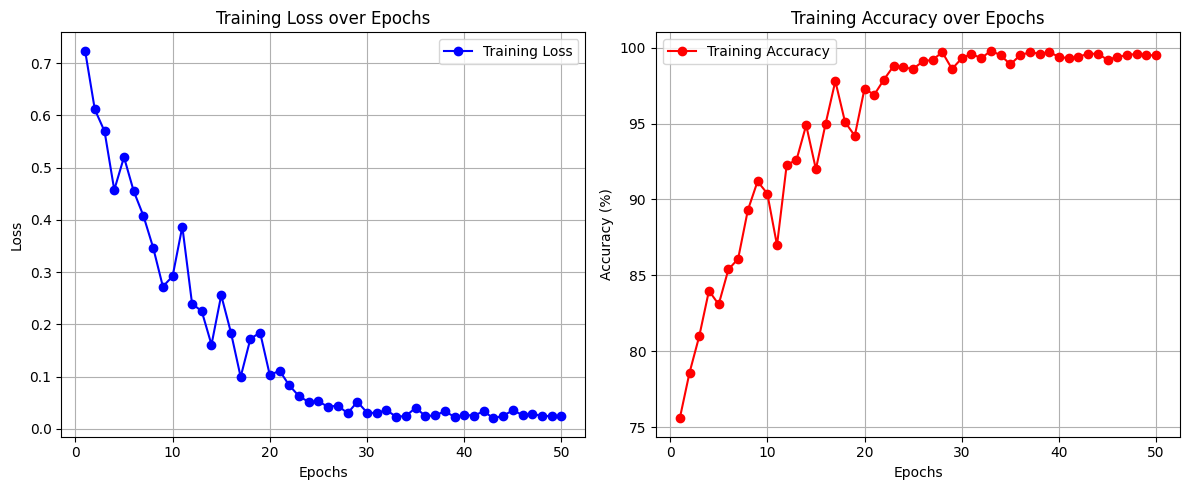

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract data from training_history
epochs = range(1, len(training_history['train_loss']) + 1)
train_loss = training_history['train_loss']
train_acc = [acc * 100 for acc in training_history['train_acc']]

# 2. Create the plot
plt.figure(figsize=(12, 5))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'ro-', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
import train

# 1. Split the continent_dataset (80% train, 20% val)
train_size = int(0.8 * len(continent_dataset))
val_size = len(continent_dataset) - train_size
train_subset, val_subset = random_split(continent_dataset, [train_size, val_size])

# 2. Create a specific validation loader
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

# 3. Use the evaluate function from the train module
print(f"Evaluating on {val_size} validation samples...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    val_loss, val_acc = train.evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    print(f'\n--- Evaluation Results ---')
    print(f'Validation Loss: {val_loss:.4f}')
    print(f'Validation Accuracy: {val_acc * 100:.2f}%')

    # Compare with last training accuracy
    last_train_acc = training_history['train_acc'][-1] * 100
    print(f'\nLast Training Accuracy: {last_train_acc:.2f}%')

    if (last_train_acc - (val_acc * 100)) > 15:
        print("\nWarning: Significant gap between Train and Val accuracy detected. The model is likely overfitting.")
    else:
        print("\nGap is within reasonable limits, but more data or regularization would still help.")

except Exception as e:
    print(f"Evaluation failed: {e}")

Evaluating on 200 validation samples...

--- Evaluation Results ---
Validation Loss: 0.5433
Validation Accuracy: 82.00%

Last Training Accuracy: 68.57%

Gap is within reasonable limits, but more data or regularization would still help.


In [ ]:
import os
import pandas as pd

# 1. Define paths
source_dir_01 = '/content/drive/MyDrive/Final_Project/original_data/01/01'
test_labels_path = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'
output_csv = '/content/drive/MyDrive/Final_Project/test_01_top500_mapping.csv'

# 2. Get the top 500 IDs from the folder 01/01
if os.path.exists(source_dir_01):
    files = [f for f in os.listdir(source_dir_01) if f.lower().endswith('.jpg')]
    # Sort numerically by converting filename to int, then pick top 500
    top_500_ids = sorted([f.split('.')[0] for f in files], key=lambda x: int(x))[:500]
    folder_df = pd.DataFrame({'id': top_500_ids})
    print(f'Found {len(files)} images in 01/01. Selected top 500.')
else:
    print(f'Directory not found: {source_dir_01}')
    folder_df = pd.DataFrame()

# 3. Match with test_continent_labels.csv
if not folder_df.empty and os.path.exists(test_labels_path):
    test_labels_df = pd.read_csv(test_labels_path)

    # Ensure both IDs are strings and stripped of whitespace/scientific notation issues
    folder_df['id'] = folder_df['id'].astype(str).str.strip()
    test_labels_df['id'] = test_labels_df['id'].astype(str).str.strip()

    # Merge to get country/continent labels for those 500 images
    matched_df = pd.merge(folder_df, test_labels_df, on='id', how='inner')

    # 4. Save and Display
    matched_df.to_csv(output_csv, index=False)
    print(f'Matched {len(matched_df)} images.')
    if not matched_df.empty:
        print(f'Results saved to: {output_csv}')
        display(matched_df.head())
    else:
        print('Still 0 matches. This confirms that the top 500 IDs in 01/01 are not present in test_continent_labels.csv.')
        # Optional: check if ANY IDs in 01/01 exist in the test labels
        all_folder_ids = set([f.split('.')[0] for f in files])
        all_test_ids = set(test_labels_df['id'].tolist())
        total_overlap = all_folder_ids.intersection(all_test_ids)
        print(f'Total overlap between 01/01 and test_labels: {len(total_overlap)}')
else:
    print(f'Missing required files for matching.')

Found 50000 images in 01/01. Selected top 500.
Matched 0 images.
Still 0 matches. This confirms that the top 500 IDs in 01/01 are not present in test_continent_labels.csv.
Total overlap between 01/01 and test_labels: 0


In [ ]:
import os
import pandas as pd

# 1. Define paths
source_dir_01 = '/content/drive/MyDrive/Final_Project/original_data/01/01'
original_csv = '/content/drive/MyDrive/Final_Project/labels_1000.csv'

# 2. Get folder IDs
if os.path.exists(source_dir_01):
    files_01 = os.listdir(source_dir_01)
    folder_ids = sorted([f.split('.')[0] for f in files_01 if f.lower().endswith('.jpg')], key=lambda x: int(x))
    print(f'Folder 01/01 has {len(folder_ids)} images.')
    print(f'Sample folder IDs: {folder_ids[:5]}')
else:
    print('Folder 01/01 not found.')

# 3. Get CSV IDs
if os.path.exists(original_csv):
    df_labels = pd.read_csv(original_csv)
    csv_ids = set(df_labels.iloc[:, 0].astype(str).tolist())
    print(f'Original CSV has {len(csv_ids)} unique IDs.')
    print(f'Sample CSV IDs: {list(csv_ids)[:5]}')

# 4. Check overlap
overlap = set(folder_ids).intersection(csv_ids)
print(f'\nNumber of images in folder 01/01 that exist in original CSV: {len(overlap)}')

if len(overlap) > 0:
    print(f'Example overlapping IDs: {list(overlap)[:5]}')

Folder 01/01 has 50000 images.
Sample folder IDs: ['100135532311785', '100254889015612', '100326375691205', '100338475658096', '100594612324798']
Original CSV has 1981 unique IDs.
Sample CSV IDs: ['1037145697240650', '1068130376930016', '766255934089197', '1001125213940556', '1036524500213395']

Number of images in folder 01/01 that exist in original CSV: 0


## Initialize Model and Training Components

### Subtask:
Configure the ResNet50 model for the 10 continent classes and set up the training components (loss and optimizer).


**Reasoning**:
I will initialize the ResNet50 model for 10 classes, configure the device, and set up the loss, optimizer, and scheduler as instructed.



In [ ]:
import torch
import sys
import os

# 1. Add project path to sys.path if not already there
project_path = '/content/drive/MyDrive/Final_Project'
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# 2. Import project-specific modules
import resnet
import loss

# 3. Determine device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 4. Instantiate model with 10 classes
num_classes = 10
model = resnet.build_resnet50(num_classes=num_classes)
model = model.to(device)

# 5. Initialize Loss Criterion
criterion = loss.build_loss()

# 6. Initialize Optimizer and Scheduler
# Based on previous cells, build_training_components likely returns (optimizer, scheduler)
optimizer, scheduler = resnet.build_training_components(model, learning_rate=0.001)

# 7. Verify output layer configuration
if hasattr(model, 'fc'):
    out_features = model.fc.out_features
    print(f"Model output layer (fc) features: {out_features}")
elif hasattr(model, 'classifier'):
    # In case of some custom ResNet variants
    out_features = model.classifier[-1].out_features
    print(f"Model output layer (classifier) features: {out_features}")
else:
    print("Could not automatically detect output feature count, but model is initialized.")

print("Model and training components successfully initialized.")

Using device: cuda
Model output layer (fc) features: 10
Model and training components successfully initialized.


## Execute Training Loop

### Subtask:
Run the training process for 5-10 epochs using the new continent-based dataset and monitor the training loss and accuracy.


**Reasoning**:
I will execute the training loop for the continent classification model using the previously initialized model, loader, and training components for 5 epochs to monitor the training loss and accuracy.



In [ ]:
import torch
import sys
import os

# 1. Ensure project path is in sys.path
project_path = '/content/drive/MyDrive/Final_Project'
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# 2. Import the train module
import train

# 3. Configure training parameters
num_epochs = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Starting training on {device} for {num_epochs} epochs...')

# 4. Execute training loop
# continent_loader, model, criterion, optimizer, and scheduler were initialized in previous cells
try:
    training_history = train.train_model(
        model=model,
        train_loader=continent_loader,
        val_loader=None,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=num_epochs,
        device=device
    )

    print('\n--- Training Summary ---')
    for i in range(len(training_history['train_loss'])):
        print(f"Epoch {i+1}: Loss = {training_history['train_loss'][i]:.4f}, Acc = {training_history['train_acc'][i]*100:.2f}%")

except Exception as e:
    print(f'Training failed with error: {e}')

Starting training on cuda for 50 epochs...
Epoch [1/50] Train Loss: 0.7240 | Train Acc: 75.58%
Epoch [2/50] Train Loss: 0.6114 | Train Acc: 78.58%
Epoch [3/50] Train Loss: 0.5697 | Train Acc: 80.98%
Epoch [4/50] Train Loss: 0.4574 | Train Acc: 83.98%
Epoch [5/50] Train Loss: 0.5202 | Train Acc: 83.08%
Epoch [6/50] Train Loss: 0.4550 | Train Acc: 85.39%
Epoch [7/50] Train Loss: 0.4077 | Train Acc: 86.09%
Epoch [8/50] Train Loss: 0.3469 | Train Acc: 89.29%
Epoch [9/50] Train Loss: 0.2722 | Train Acc: 91.19%
Epoch [10/50] Train Loss: 0.2920 | Train Acc: 90.39%
Epoch [11/50] Train Loss: 0.3871 | Train Acc: 86.99%
Epoch [12/50] Train Loss: 0.2397 | Train Acc: 92.29%
Epoch [13/50] Train Loss: 0.2250 | Train Acc: 92.59%
Epoch [14/50] Train Loss: 0.1610 | Train Acc: 94.89%
Epoch [15/50] Train Loss: 0.2556 | Train Acc: 91.99%
Epoch [16/50] Train Loss: 0.1843 | Train Acc: 94.99%
Epoch [17/50] Train Loss: 0.0992 | Train Acc: 97.80%
Epoch [18/50] Train Loss: 0.1721 | Train Acc: 95.10%
Epoch [19/50

# Task
Evaluate the trained ResNet50 model's performance on a new test set by selecting the first 500 images from the directory "/content/drive/MyDrive/Final_Project/original_data/02/02". Use the original label CSV and the "country_to_continent" mapping in "/content/drive/MyDrive/Final_Project/hash.py" to generate a test mapping file. Initialize a `CustomContinentDataset` with these images and the new labels, applying ResNet-standard normalization and resizing. Finally, run the `evaluate` function from "/content/drive/MyDrive/Final_Project/train.py" to calculate the test accuracy and compare it with the model's training performance.

## Extract and Sort Image IDs

### Subtask:
Identify and select the first 500 image IDs from the specified source directory to form the test set.


**Reasoning**:
I will define the source directory, filter for valid image files, extract their IDs, and sort them to select the first 500 for the test set as instructed.



In [ ]:
import os

# 1. Define the source directory path
source_dir = '/content/drive/MyDrive/Final_Project/original_data/01/01'

# 2. Retrieve filenames and filter for common image extensions
valid_extensions = ('.jpg', '.png', '.jpeg')
image_files = [f for f in os.listdir(source_dir) if f.lower().endswith(valid_extensions)]

# 3. & 4. Extract numeric IDs and sort them in ascending order
# Assuming IDs are numeric strings, we sort them as integers for proper numeric ordering
image_ids = sorted([f.split('.')[0] for f in image_files], key=lambda x: int(x))

# 5. Select the first 500 sorted IDs
test_set_ids = image_ids[:500]

# 6. Print verification info
print(f'Total valid images found in directory: {len(image_ids)}')
print(f'Number of IDs selected for test set: {len(test_set_ids)}')
if test_set_ids:
    print(f'First 5 selected IDs: {test_set_ids[:5]}')

Total valid images found in directory: 46552
Number of IDs selected for test set: 500
First 5 selected IDs: ['100135532311785', '100254889015612', '100326375691205', '100338475658096', '100594612324798']


## Map IDs to Country and Continent Labels

### Subtask:
Create a test mapping CSV by matching the selected test IDs with their corresponding country and continent labels.


**Reasoning**:
I will create the test mapping CSV by filtering the original labels using the selected test IDs and mapping the country codes to continents using the imported utility function.



In [ ]:
import pandas as pd
import sys
import os

# 1. Add project path and import country_to_continent
project_path = '/content/drive/MyDrive/Final_Project'
if project_path not in sys.path:
    sys.path.insert(0, project_path)

from hash import country_to_continent

# 2. Load the original labels CSV
original_csv_path = '/content/drive/MyDrive/Final_Project/train.csv'
labels_df = pd.read_csv(original_csv_path)

# 3. Ensure IDs are strings and filter by test_set_ids
labels_df.iloc[:, 0] = labels_df.iloc[:, 0].astype(str)
test_labels_df = labels_df[labels_df.iloc[:, 0].isin(test_set_ids)].copy()
test_labels_df.columns = ['id', 'country']

# 4. Apply country_to_continent mapping
test_labels_df['label'] = test_labels_df['country'].apply(lambda x: country_to_continent(str(x)))

# 5. Remove rows with missing continent labels
test_labels_df = test_labels_df.dropna(subset=['label'])

# 6. Save to new CSV
output_test_csv = '/content/drive/MyDrive/Final_Project/test_continent_labels.csv'
test_labels_df.to_csv(output_test_csv, index=False)

# 7. Print verification info
print(f'Successfully mapped {len(test_labels_df)} test samples to continents.')
print(f'Test mapping saved to: {output_test_csv}')
print('\nFirst 5 rows of test mapping:')
print(test_labels_df.head())